# Credit Scoring PD(probability of default) Model

# Pre-Processing

In [58]:
# Read libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn import metrics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [59]:
data = pd.read_csv(r"C:/Users/aksta/Desktop/python lessons/credit_score.csv")
data

,ID,CustomerID,Month,Name,Age,SSN,Occupation,AnnualIncome,MonthlyInhandSalary,NumBankAccounts,NumCreditCard,InterestRate,NumofLoan,TypeofLoan,Delayfromduedate,NumofDelayedPayment,ChangedCreditLimit,NumCreditInquiries,OutstandingDebt,CreditUtilizationRatio,PaymentofMinAmount,TotalEMIpermonth,Amountinvestedmonthly,PaymentBehaviour,MonthlyBalance,CreditScore
0,0x1602,CUS0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7.0,11.27,4.0,809.98,26.822620,No,49.574949,80.415295,HighspentSmallvaluepayments,312.494089,Good
1,0x1603,CUS0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,809.98,31.944960,No,49.574949,118.280222,LowspentLargevaluepayments,284.629163,Good
2,0x1604,CUS0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7.0,NaN,4.0,809.98,28.609352,No,49.574949,81.699521,LowspentMediumvaluepayments,331.209863,Good
3,0x1605,CUS0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4.0,6.27,4.0,809.98,31.377862,No,49.574949,199.458074,LowspentSmallvaluepayments,223.451310,Good
4,0x1606,CUS0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,809.98,24.797347,No,49.574949,41.420153,HighspentMediumvaluepayments,341.489231,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87490,0x25fe8,CUS0x942c,March,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",20,6.0,9.50,3.0,502.38,39.323569,No,35.104023,140.581403,HighspentMediumvaluepayments,410.256158,Poor
87491,0x25fe9,CUS0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",23,7.0,11.50,3.0,502.38,34.663572,No,35.104023,60.971333,HighspentLargevaluepayments,479.866228,Poor
87492,0x25fea,CUS0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",18,7.0,11.50,3.0,502.38,40.565631,No,35.104023,54.185950,HighspentMediumvaluepayments,496.651610,Poor
87493,0x25feb,CUS0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,5729,2,"Auto Loan, and Student Loan",27,6.0,11.50,3.0,502.38,41.255522,No,35.104023,24.028477,HighspentLargevaluepayments,516.809083,Poor


In [60]:
# expand columns

pd.set_option('display.max_columns', None) 

In [61]:
data.describe(include='all')

,ID,CustomerID,Month,Name,Age,SSN,Occupation,AnnualIncome,MonthlyInhandSalary,NumBankAccounts,NumCreditCard,InterestRate,NumofLoan,TypeofLoan,Delayfromduedate,NumofDelayedPayment,ChangedCreditLimit,NumCreditInquiries,OutstandingDebt,CreditUtilizationRatio,PaymentofMinAmount,TotalEMIpermonth,Amountinvestedmonthly,PaymentBehaviour,MonthlyBalance,CreditScore
count,87495,87495,87495,78779,87495.000000,87495,81317,8.749500e+04,74319.000000,87495.000000,87495.000000,87495.000000,87495.000000,77583,87495.000000,81400.000000,85654.000000,85789.000000,87495.000000,87495.000000,87495,87495.000000,79786.000000,87495,86437.000000,87495
unique,87495,12500,8,10139,NaN,12501,15,NaN,NaN,NaN,NaN,NaN,NaN,6260,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,7,NaN,3
top,0x1602,CUS0xd40,January,Langep,NaN,#F%$D@*&8,Lawyer,NaN,NaN,NaN,NaN,NaN,NaN,Not Specified,NaN,NaN,NaN,NaN,NaN,NaN,Yes,NaN,NaN,LowspentSmallvaluepayments,NaN,Standard
freq,1,8,10970,41,NaN,4857,5762,NaN,NaN,NaN,NaN,NaN,NaN,1208,NaN,NaN,NaN,NaN,NaN,NaN,45810,NaN,NaN,22237,NaN,46651
mean,NaN,NaN,NaN,NaN,110.467364,NaN,NaN,1.802404e+05,4193.181285,17.112646,22.664792,73.050871,7.019841,NaN,21.060403,30.904324,10.385851,27.734302,1426.716635,32.290526,NaN,1388.517947,195.482486,NaN,402.281023,NaN
std,NaN,NaN,NaN,NaN,686.549658,NaN,NaN,1.455212e+06,3179.195651,117.428586,129.806747,467.727237,60.352339,NaN,14.864558,225.495250,6.776714,193.011903,1155.824064,5.112418,NaN,8248.832131,199.357752,NaN,213.309331,NaN
min,NaN,NaN,NaN,NaN,-500.000000,NaN,NaN,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,0.000000,NaN,-5.000000,-3.000000,-6.490000,0.000000,0.230000,20.000000,NaN,0.000000,0.000000,NaN,0.007760,NaN
25%,NaN,NaN,NaN,NaN,24.000000,NaN,NaN,1.943348e+04,1626.677917,3.000000,4.000000,8.000000,1.000000,NaN,10.000000,9.000000,5.340000,3.000000,566.400000,28.059063,NaN,30.453014,72.220853,NaN,270.107156,NaN
50%,NaN,NaN,NaN,NaN,33.000000,NaN,NaN,3.757975e+04,3095.905000,6.000000,5.000000,13.000000,3.000000,NaN,18.000000,14.000000,9.410000,6.000000,1166.230000,32.322206,NaN,69.285581,128.921405,NaN,336.698600,NaN
75%,NaN,NaN,NaN,NaN,42.000000,NaN,NaN,7.288608e+04,5967.930000,7.000000,7.000000,20.000000,5.000000,NaN,28.000000,18.000000,14.840000,9.000000,1948.980000,36.495606,NaN,161.405543,236.802042,NaN,470.180816,NaN


In [62]:
data.dtypes

ID                            str
CustomerID                    str
Month                         str
Name                          str
Age                         int64
SSN                           str
Occupation                    str
AnnualIncome              float64
MonthlyInhandSalary       float64
NumBankAccounts             int64
NumCreditCard               int64
InterestRate                int64
NumofLoan                   int64
TypeofLoan                    str
Delayfromduedate            int64
NumofDelayedPayment       float64
ChangedCreditLimit        float64
NumCreditInquiries        float64
OutstandingDebt           float64
CreditUtilizationRatio    float64
PaymentofMinAmount            str
TotalEMIpermonth          float64
Amountinvestedmonthly     float64
PaymentBehaviour              str
MonthlyBalance            float64
CreditScore                   str
dtype: object

In [63]:
data.drop(data[['CustomerID', 'ID', 'Name', 'SSN', 'TypeofLoan' ]],axis=1, inplace=True)

In [64]:
def to_binary(score):
    if score == 'Poor':
        return 1
    else:
        return 0

data['target'] = data['CreditScore'].apply(to_binary)

data

,Month,Age,Occupation,AnnualIncome,MonthlyInhandSalary,NumBankAccounts,NumCreditCard,InterestRate,NumofLoan,Delayfromduedate,NumofDelayedPayment,ChangedCreditLimit,NumCreditInquiries,OutstandingDebt,CreditUtilizationRatio,PaymentofMinAmount,TotalEMIpermonth,Amountinvestedmonthly,PaymentBehaviour,MonthlyBalance,CreditScore,target
0,January,23,Scientist,19114.12,1824.843333,3,4,3,4,3,7.0,11.27,4.0,809.98,26.822620,No,49.574949,80.415295,HighspentSmallvaluepayments,312.494089,Good,0
1,February,23,Scientist,19114.12,NaN,3,4,3,4,-1,NaN,11.27,4.0,809.98,31.944960,No,49.574949,118.280222,LowspentLargevaluepayments,284.629163,Good,0
2,March,-500,Scientist,19114.12,NaN,3,4,3,4,3,7.0,NaN,4.0,809.98,28.609352,No,49.574949,81.699521,LowspentMediumvaluepayments,331.209863,Good,0
3,April,23,Scientist,19114.12,NaN,3,4,3,4,5,4.0,6.27,4.0,809.98,31.377862,No,49.574949,199.458074,LowspentSmallvaluepayments,223.451310,Good,0
4,May,23,Scientist,19114.12,1824.843333,3,4,3,4,6,NaN,11.27,4.0,809.98,24.797347,No,49.574949,41.420153,HighspentMediumvaluepayments,341.489231,Good,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87490,March,25,Mechanic,39628.99,3359.415833,4,6,7,2,20,6.0,9.50,3.0,502.38,39.323569,No,35.104023,140.581403,HighspentMediumvaluepayments,410.256158,Poor,1
87491,April,25,Mechanic,39628.99,3359.415833,4,6,7,2,23,7.0,11.50,3.0,502.38,34.663572,No,35.104023,60.971333,HighspentLargevaluepayments,479.866228,Poor,1
87492,May,25,Mechanic,39628.99,3359.415833,4,6,7,2,18,7.0,11.50,3.0,502.38,40.565631,No,35.104023,54.185950,HighspentMediumvaluepayments,496.651610,Poor,1
87493,June,25,Mechanic,39628.99,3359.415833,4,6,5729,2,27,6.0,11.50,3.0,502.38,41.255522,No,35.104023,24.028477,HighspentLargevaluepayments,516.809083,Poor,1


In [65]:
data.drop(data[['CreditScore']],axis=1, inplace=True)

In [4]:
# Drop Unnecessary columns

In [66]:
data

,Month,Age,Occupation,AnnualIncome,MonthlyInhandSalary,NumBankAccounts,NumCreditCard,InterestRate,NumofLoan,Delayfromduedate,NumofDelayedPayment,ChangedCreditLimit,NumCreditInquiries,OutstandingDebt,CreditUtilizationRatio,PaymentofMinAmount,TotalEMIpermonth,Amountinvestedmonthly,PaymentBehaviour,MonthlyBalance,target
0,January,23,Scientist,19114.12,1824.843333,3,4,3,4,3,7.0,11.27,4.0,809.98,26.822620,No,49.574949,80.415295,HighspentSmallvaluepayments,312.494089,0
1,February,23,Scientist,19114.12,NaN,3,4,3,4,-1,NaN,11.27,4.0,809.98,31.944960,No,49.574949,118.280222,LowspentLargevaluepayments,284.629163,0
2,March,-500,Scientist,19114.12,NaN,3,4,3,4,3,7.0,NaN,4.0,809.98,28.609352,No,49.574949,81.699521,LowspentMediumvaluepayments,331.209863,0
3,April,23,Scientist,19114.12,NaN,3,4,3,4,5,4.0,6.27,4.0,809.98,31.377862,No,49.574949,199.458074,LowspentSmallvaluepayments,223.451310,0
4,May,23,Scientist,19114.12,1824.843333,3,4,3,4,6,NaN,11.27,4.0,809.98,24.797347,No,49.574949,41.420153,HighspentMediumvaluepayments,341.489231,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87490,March,25,Mechanic,39628.99,3359.415833,4,6,7,2,20,6.0,9.50,3.0,502.38,39.323569,No,35.104023,140.581403,HighspentMediumvaluepayments,410.256158,1
87491,April,25,Mechanic,39628.99,3359.415833,4,6,7,2,23,7.0,11.50,3.0,502.38,34.663572,No,35.104023,60.971333,HighspentLargevaluepayments,479.866228,1
87492,May,25,Mechanic,39628.99,3359.415833,4,6,7,2,18,7.0,11.50,3.0,502.38,40.565631,No,35.104023,54.185950,HighspentMediumvaluepayments,496.651610,1
87493,June,25,Mechanic,39628.99,3359.415833,4,6,5729,2,27,6.0,11.50,3.0,502.38,41.255522,No,35.104023,24.028477,HighspentLargevaluepayments,516.809083,1


In [67]:
data.isnull().sum()


Month                         0
Age                           0
Occupation                 6178
AnnualIncome                  0
MonthlyInhandSalary       13176
NumBankAccounts               0
NumCreditCard                 0
InterestRate                  0
NumofLoan                     0
Delayfromduedate              0
NumofDelayedPayment        6095
ChangedCreditLimit         1841
NumCreditInquiries         1706
OutstandingDebt               0
CreditUtilizationRatio        0
PaymentofMinAmount            0
TotalEMIpermonth              0
Amountinvestedmonthly      7709
PaymentBehaviour              0
MonthlyBalance             1058
target                        0
dtype: int64

In [69]:
for col in data.columns:
    if data[col].isna().sum() > 0:
        if pd.api.types.is_numeric_dtype(data[col]):
            data[col] = data[col].fillna(data[col].mean())
        else:
            data[col] = data[col].fillna(data[col].mode()[0])
data.isnull().sum()


Month                     0
Age                       0
Occupation                0
AnnualIncome              0
MonthlyInhandSalary       0
NumBankAccounts           0
NumCreditCard             0
InterestRate              0
NumofLoan                 0
Delayfromduedate          0
NumofDelayedPayment       0
ChangedCreditLimit        0
NumCreditInquiries        0
OutstandingDebt           0
CreditUtilizationRatio    0
PaymentofMinAmount        0
TotalEMIpermonth          0
Amountinvestedmonthly     0
PaymentBehaviour          0
MonthlyBalance            0
target                    0
dtype: int64

In [70]:
inputs = data.drop('target', axis=1)

dependant = data['target']


In [71]:
X_train, X_test, y_train, y_test = train_test_split(inputs, dependant, test_size=0.2, random_state=42)

In [72]:
numeric_columns = X_train.select_dtypes(include="number").columns
display(numeric_columns)

categorical_columns = X_train.select_dtypes(include=["object", "category"]).columns
display(categorical_columns)

Index(['Age', 'AnnualIncome', 'MonthlyInhandSalary', 'NumBankAccounts',
       'NumCreditCard', 'InterestRate', 'NumofLoan', 'Delayfromduedate',
       'NumofDelayedPayment', 'ChangedCreditLimit', 'NumCreditInquiries',
       'OutstandingDebt', 'CreditUtilizationRatio', 'TotalEMIpermonth',
       'Amountinvestedmonthly', 'MonthlyBalance'],
      dtype='str')

C:\Users\aksta\AppData\Local\Temp\ipykernel_28764\965181280.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_train.select_dtypes(include=["object", "category"]).columns


Index(['Month', 'Occupation', 'PaymentofMinAmount', 'PaymentBehaviour'], dtype='str')

In [73]:
woe_maps = {}
bin_maps = {}

X_train_woe = X_train.copy()
X_train_woe['target'] = y_train.values

features = X_train.columns
display(features)

Index(['Month', 'Age', 'Occupation', 'AnnualIncome', 'MonthlyInhandSalary',
       'NumBankAccounts', 'NumCreditCard', 'InterestRate', 'NumofLoan',
       'Delayfromduedate', 'NumofDelayedPayment', 'ChangedCreditLimit',
       'NumCreditInquiries', 'OutstandingDebt', 'CreditUtilizationRatio',
       'PaymentofMinAmount', 'TotalEMIpermonth', 'Amountinvestedmonthly',
       'PaymentBehaviour', 'MonthlyBalance'],
      dtype='str')

In [74]:
X_train_woe

,Month,Age,Occupation,AnnualIncome,MonthlyInhandSalary,NumBankAccounts,NumCreditCard,InterestRate,NumofLoan,Delayfromduedate,NumofDelayedPayment,ChangedCreditLimit,NumCreditInquiries,OutstandingDebt,CreditUtilizationRatio,PaymentofMinAmount,TotalEMIpermonth,Amountinvestedmonthly,PaymentBehaviour,MonthlyBalance,target
27300,August,56,Lawyer,49790.500,4060.208333,6,5,15,2,27,9.0,3.340000,4.0,1021.50,32.045022,No,63.078418,98.907776,HighspentLargevaluepayments,484.034640,0
81811,May,39,Writer,57264.000,4933.000000,7,6,4987,8,42,17.0,0.500000,15.0,4730.75,31.166788,NM,283.622321,299.442124,LowspentLargevaluepayments,180.235556,0
59756,March,27,Developer,38726.470,4193.181285,0,4,10,0,8,11.0,10.385851,4.0,259.59,27.622234,No,0.000000,405.256776,LowspentSmallvaluepayments,231.463807,0
33786,March,25,Entrepreneur,12302.195,822.182917,7,7,7,0,14,18.0,5.540000,1.0,419.95,25.602278,NM,0.000000,82.382293,LowspentMediumvaluepayments,279.835999,0
29284,August,53,Mechanic,63051.860,4193.181285,2,5,3,1,3,12.0,4.680000,5.0,1006.09,26.882552,NM,47.525700,154.820231,other,586.586235,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,April,32,Engineer,41655.160,3743.263333,3,4,5,2,29,19.0,5.720000,4.0,1240.64,26.347284,No,66.912509,85.178042,HighspentLargevaluepayments,462.235782,0
54886,January,37,Musician,8137.580,554.131667,6,4,17,3,6,13.0,7.700000,5.0,998.45,40.562153,NM,14.302914,27.569271,LowspentSmallvaluepayments,303.540982,0
76820,June,30,Teacher,24821.360,2106.446667,1411,5,7,0,6,20.0,2.250000,6.0,298.88,26.178291,No,0.000000,126.369096,HighspentSmallvaluepayments,344.275570,0
860,March,17,Journalist,19163.220,1346.935000,3,7,7,2,21,18.0,5.760000,5.0,2226.37,31.191258,Yes,24.175648,167.878119,other,232.639733,0


In [13]:
# Transform both numeric and categorical variable's values into WOE

In [77]:
for var in features:

    if pd.api.types.is_numeric_dtype(X_train[var]):

        q1 = X_train[var].quantile(0.25)
        q2 = X_train[var].quantile(0.50)
        q3 = X_train[var].quantile(0.75)

        bins = [-np.inf, q1, q2, q3, np.inf]

        train_bin = pd.cut(X_train[var],bins=bins,duplicates='drop')
        # duplicates='drop' is used because quantile values can sometimes be the same.

        grouped = X_train_woe.groupby([train_bin, 'target'], observed=False)['target'].count().unstack()

        grouped['woe'] = np.log((grouped[0] / grouped[0].sum()) / (grouped[1] / grouped[1].sum()))

        woe_maps[var] = grouped['woe']
        bin_maps[var] = bins

        X_train_woe[var + '_woe'] = train_bin.map(grouped['woe'])

    else:

        grouped = X_train_woe.groupby([var, 'target'])['target'].count().unstack()

        grouped['woe'] = np.log((grouped[0] / grouped[0].sum()) / (grouped[1] / grouped[1].sum()))

        woe_maps[var] = grouped['woe']

        X_train_woe[var + '_woe'] = X_train[var].map(grouped['woe'])

In [78]:
X_train_woe

,Month,Age,Occupation,AnnualIncome,MonthlyInhandSalary,NumBankAccounts,NumCreditCard,InterestRate,NumofLoan,Delayfromduedate,NumofDelayedPayment,ChangedCreditLimit,NumCreditInquiries,OutstandingDebt,CreditUtilizationRatio,PaymentofMinAmount,TotalEMIpermonth,Amountinvestedmonthly,PaymentBehaviour,MonthlyBalance,target,Month_woe,Age_woe,Occupation_woe,AnnualIncome_woe,MonthlyInhandSalary_woe,NumBankAccounts_woe,NumCreditCard_woe,InterestRate_woe,NumofLoan_woe,Delayfromduedate_woe,NumofDelayedPayment_woe,ChangedCreditLimit_woe,NumCreditInquiries_woe,OutstandingDebt_woe,CreditUtilizationRatio_woe,PaymentofMinAmount_woe,TotalEMIpermonth_woe,Amountinvestedmonthly_woe,PaymentBehaviour_woe,MonthlyBalance_woe
27300,August,56,Lawyer,49790.500,4060.208333,6,5,15,2,27,9.0,3.340000,4.0,1021.50,32.045022,No,63.078418,98.907776,HighspentLargevaluepayments,484.034640,0,0.012338,0.498390,0.038151,-0.187419,-0.167788,0.330227,0.066187,-0.035046,0.310941,-0.102881,0.653657,0.108076,0.559737,1.207094,-0.008178,0.985935,-0.136998,-0.131022,0.389248,0.676101
81811,May,39,Writer,57264.000,4933.000000,7,6,4987,8,42,17.0,0.500000,15.0,4730.75,31.166788,NM,283.622321,299.442124,LowspentLargevaluepayments,180.235556,0,-0.041589,-0.062361,-0.050750,-0.187419,-0.167788,-0.375134,-0.081366,-1.380031,-0.964246,-1.105627,-0.281616,0.108076,-1.076685,-1.233397,-0.008178,-0.026979,-0.104868,0.353127,0.070431,-0.482604
59756,March,27,Developer,38726.470,4193.181285,0,4,10,0,8,11.0,10.385851,4.0,259.59,27.622234,No,0.000000,405.256776,LowspentSmallvaluepayments,231.463807,0,0.025404,-0.114801,0.020058,-0.187419,-0.167788,0.767866,1.069832,1.146150,0.923361,1.076205,0.327913,0.133144,0.559737,1.275098,-0.082587,0.985935,0.446102,0.353127,-0.319237,-0.482604
33786,March,25,Entrepreneur,12302.195,822.182917,7,7,7,0,14,18.0,5.540000,1.0,419.95,25.602278,NM,0.000000,82.382293,LowspentMediumvaluepayments,279.835999,0,0.025404,-0.114801,-0.084354,-0.544330,-0.471814,-0.375134,-0.081366,0.977676,0.923361,0.497926,-0.281616,0.033880,1.119382,1.275098,-0.082587,-0.026979,0.446102,-0.131022,-0.072871,-0.242499
29284,August,53,Mechanic,63051.860,4193.181285,2,5,3,1,3,12.0,4.680000,5.0,1006.09,26.882552,NM,47.525700,154.820231,other,586.586235,0,0.012338,0.498390,-0.054544,-0.187419,-0.167788,0.767866,0.066187,0.977676,0.923361,1.076205,0.327913,0.108076,0.559737,1.207094,-0.082587,-0.026979,-0.136998,0.018258,0.007110,0.676101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,April,32,Engineer,41655.160,3743.263333,3,4,5,2,29,19.0,5.720000,4.0,1240.64,26.347284,No,66.912509,85.178042,HighspentLargevaluepayments,462.235782,0,-0.002860,-0.114801,-0.051975,-0.187419,0.178280,0.767866,1.069832,0.977676,0.310941,-1.105627,-0.281616,0.033880,0.559737,-0.341402,-0.082587,0.985935,-0.136998,-0.131022,0.389248,0.217280
54886,January,37,Musician,8137.580,554.131667,6,4,17,3,6,13.0,7.700000,5.0,998.45,40.562153,NM,14.302914,27.569271,LowspentSmallvaluepayments,303.540982,0,0.024882,-0.062361,0.035950,-0.544330,-0.471814,0.330227,1.069832,-0.035046,0.310941,1.076205,0.327913,0.033880,0.559737,1.207094,0.087002,-0.026979,0.446102,-0.201090,-0.319237,-0.242499
76820,June,30,Teacher,24821.360,2106.446667,1411,5,7,0,6,20.0,2.250000,6.0,298.88,26.178291,No,0.000000,126.369096,HighspentSmallvaluepayments,344.275570,0,-0.017978,-0.114801,-0.092219,0.231851,0.178280,-0.789894,0.066187,0.977676,0.923361,1.076205,-0.647001,0.108076,0.559737,1.275098,-0.082587,0.985935,0.446102,-0.131022,0.090542,0.217280
860,March,17,Journalist,19163.220,1346.935000,3,7,7,2,21,18.0,5.760000,5.0,2226.37,31.191258,Yes,24.175648,167.878119,other,232.639733,0,0.025404,-0.224289,0.050708,-0.544330,-0.471814,0.767866,-0.081366,0.977676,0.310941,-0.102881,-0.281616,0.033880,0.559737,-1.233397,-0.008178,-0.475833,0.446102,0.018258,0.007110,-0.482604


In [80]:
X_test_woe = X_test.copy()

for var in features:

    if pd.api.types.is_numeric_dtype(X_train[var]):

        test_bin = pd.cut(X_test[var],bins=bin_maps[var],duplicates='drop')

        X_test_woe[var + '_woe'] = test_bin.map(woe_maps[var])

    else:

        X_test_woe[var + '_woe'] = X_test[var].map(woe_maps[var])
        
X_test_woe

,Month,Age,Occupation,AnnualIncome,MonthlyInhandSalary,NumBankAccounts,NumCreditCard,InterestRate,NumofLoan,Delayfromduedate,NumofDelayedPayment,ChangedCreditLimit,NumCreditInquiries,OutstandingDebt,CreditUtilizationRatio,PaymentofMinAmount,TotalEMIpermonth,Amountinvestedmonthly,PaymentBehaviour,MonthlyBalance,Month_woe,Age_woe,Occupation_woe,AnnualIncome_woe,MonthlyInhandSalary_woe,NumBankAccounts_woe,NumCreditCard_woe,InterestRate_woe,NumofLoan_woe,Delayfromduedate_woe,NumofDelayedPayment_woe,ChangedCreditLimit_woe,NumCreditInquiries_woe,OutstandingDebt_woe,CreditUtilizationRatio_woe,PaymentofMinAmount_woe,TotalEMIpermonth_woe,Amountinvestedmonthly_woe,PaymentBehaviour_woe,MonthlyBalance_woe
7777,February,43,Mechanic,78999.96,6396.330000,8,5,20,0,42,24.000000,8.73,12.0,2062.79,25.617103,Yes,138.260606,195.482486,HighspentMediumvaluepayments,596.230831,0.012601,0.498390,-0.054544,0.675631,0.595172,-0.789894,0.066187,-0.035046,0.923361,-1.105627,-0.647001,0.033880,-1.076685,-1.233397,-0.082587,-0.475833,-0.149329,0.018258,0.177066,0.676101
13022,February,45,Writer,22517.10,1600.425000,3,5,4708,0,7,20.000000,8.32,4.0,729.74,37.578931,Yes,0.000000,96.939935,LowspentMediumvaluepayments,343.102565,0.012601,0.498390,-0.050750,0.231851,-0.471814,0.767866,0.066187,-1.380031,0.923361,1.076205,-0.647001,0.033880,0.559737,1.207094,0.087002,-0.475833,0.446102,-0.131022,-0.072871,0.217280
47762,August,31,Scientist,145056.64,11965.053330,4,5,11,6,12,14.000000,15.80,9.0,529.67,36.392328,Yes,474.930450,208.712255,other,752.862628,0.012338,-0.114801,-0.078843,0.675631,0.595172,0.330227,0.066187,1.146150,-0.964246,0.497926,0.327913,-0.255720,-0.475860,1.275098,0.006813,-0.475833,-0.104868,0.018258,0.007110,0.676101
75611,May,33,Architect,69981.32,4193.181285,6,10,27,6,47,15.000000,29.04,10.0,2927.56,28.267995,NM,256.236671,96.977614,HighspentMediumvaluepayments,493.963381,-0.041589,-0.114801,0.093489,-0.187419,-0.167788,0.330227,-1.242273,-1.380031,-0.964246,-1.105627,0.327913,-0.255720,-1.076685,-1.233397,-0.008178,-0.026979,-0.104868,-0.131022,0.177066,0.676101
58979,August,47,Writer,20867.67,1489.972500,1,3,11,1,13,11.000000,1.10,4.0,884.52,23.034512,NM,16.837189,192.347384,other,229.812677,0.012338,0.498390,-0.050750,0.231851,-0.471814,0.767866,1.069832,1.146150,0.923361,0.497926,0.327913,0.108076,0.559737,1.207094,-0.082587,-0.026979,0.446102,0.018258,0.007110,-0.482604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69895,June,38,Lawyer,28941.24,2474.770000,3,5,11,4,4,30.904324,6.59,6.0,562.01,26.471828,NM,74.821768,177.404322,LowspentMediumvaluepayments,275.250910,-0.017978,-0.062361,0.038151,0.231851,0.178280,0.767866,0.066187,1.146150,-0.109098,1.076205,-0.647001,0.033880,0.559737,1.275098,-0.082587,-0.026979,-0.149329,0.018258,-0.072871,-0.242499
47851,January,38,Mechanic,21114.95,1478.579167,4,7,12,1,13,8.000000,2.54,3.0,895.29,30.067449,No,9.608645,93.303248,LowspentLargevaluepayments,314.946024,0.024882,-0.062361,-0.054544,0.231851,-0.471814,0.330227,-0.081366,1.146150,0.923361,0.497926,0.653657,0.108076,1.119382,1.207094,-0.008178,0.985935,0.446102,-0.131022,0.070431,-0.242499
53387,April,28,Architect,35511.53,3154.294167,6,4,20,3,7,16.000000,9.09,0.0,1109.03,39.907529,Yes,53914.000000,223.079414,LowspentSmallvaluepayments,312.383440,-0.002860,-0.114801,0.093489,0.231851,0.178280,0.330227,1.069832,-0.035046,0.310941,1.076205,-0.281616,0.033880,1.119382,1.207094,0.087002,-0.475833,-0.104868,0.353127,-0.319237,-0.242499
68372,February,-500,Writer,8504.55,934.712500,8,6,23,7,23,24.000000,5.58,9.0,2870.02,38.084131,NM,26.610877,42.381465,LowspentSmallvaluepayments,314.478908,0.012601,-0.224289,-0.050750,-0.544330,-0.471814,-0.789894,-0.081366,-1.380031,-0.964246,-0.102881,-0.647001,0.033880,-0.475860,-1.233397,0.087002,-0.026979,0.446102,-0.201090,-0.319237,-0.242499


In [81]:
from scipy import stats


for i in X_train_woe.columns:
    
    if X_train_woe[i].dtype in ['int64', 'float64']:
        
        kstest_statistic, kstest_p_value = stats.kstest(X_train_woe[i], 'norm')
        
        print(f'Column: {i}')
        print(f'Kolmogorov-Smirnov Test:')
        print(f'Test Statistic: {kstest_statistic}')
        print(f'p-value: {kstest_p_value}')
        
        if kstest_p_value > 0.05:
            print('Data looks normally distributed')
            print()
        else:
            print('Data does not look normally distributed')
            print()

Column: Age
Kolmogorov-Smirnov Test:
Test Statistic: 0.990485170581176
p-value: 0.0
Data does not look normally distributed

Column: AnnualIncome
Kolmogorov-Smirnov Test:
Test Statistic: 1.0
p-value: 0.0
Data does not look normally distributed

Column: MonthlyInhandSalary
Kolmogorov-Smirnov Test:
Test Statistic: 1.0
p-value: 0.0
Data does not look normally distributed

Column: NumBankAccounts
Kolmogorov-Smirnov Test:
Test Statistic: 0.8892448391930289
p-value: 0.0
Data does not look normally distributed

Column: NumCreditCard
Kolmogorov-Smirnov Test:
Test Statistic: 0.9558057855328197
p-value: 0.0
Data does not look normally distributed

Column: InterestRate
Kolmogorov-Smirnov Test:
Test Statistic: 0.9508626459248422
p-value: 0.0
Data does not look normally distributed

Column: NumofLoan
Kolmogorov-Smirnov Test:
Test Statistic: 0.7242925562054296
p-value: 0.0
Data does not look normally distributed

Column: Delayfromduedate
Kolmogorov-Smirnov Test:
Test Statistic: 0.9537046765154868
p-

In [84]:
def intercorrelation(data, threshold=0.7):
    
    woe_features = data.filter(regex=r'_woe$', axis=1).copy()
    
    corr_matrix = woe_features.corr(method='spearman', numeric_only=True)
    
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    
    high_corr = corr_matrix.where(mask).stack().reset_index()
    high_corr.columns = ["Variable 1", "Variable 2", "Correlation"]
    
    high_corr = high_corr[high_corr["Correlation"].abs() >= threshold]
    
    return high_corr.reset_index(drop=True)


intercorrelated_result = intercorrelation(X_train_woe)
intercorrelated_result

,Variable 1,Variable 2,Correlation


In [85]:
fin_vars = X_train_woe.filter(regex=r'_woe$', axis=1).columns.tolist()
fin_vars

['Month_woe',
 'Age_woe',
 'Occupation_woe',
 'AnnualIncome_woe',
 'MonthlyInhandSalary_woe',
 'NumBankAccounts_woe',
 'NumCreditCard_woe',
 'InterestRate_woe',
 'NumofLoan_woe',
 'Delayfromduedate_woe',
 'NumofDelayedPayment_woe',
 'ChangedCreditLimit_woe',
 'NumCreditInquiries_woe',
 'OutstandingDebt_woe',
 'CreditUtilizationRatio_woe',
 'PaymentofMinAmount_woe',
 'TotalEMIpermonth_woe',
 'Amountinvestedmonthly_woe',
 'PaymentBehaviour_woe',
 'MonthlyBalance_woe']

In [86]:
X_train_fin=X_train_woe[fin_vars]
display(X_train_fin)

X_test_fin=X_test_woe[fin_vars]
display(X_test_fin)

,Month_woe,Age_woe,Occupation_woe,AnnualIncome_woe,MonthlyInhandSalary_woe,NumBankAccounts_woe,NumCreditCard_woe,InterestRate_woe,NumofLoan_woe,Delayfromduedate_woe,NumofDelayedPayment_woe,ChangedCreditLimit_woe,NumCreditInquiries_woe,OutstandingDebt_woe,CreditUtilizationRatio_woe,PaymentofMinAmount_woe,TotalEMIpermonth_woe,Amountinvestedmonthly_woe,PaymentBehaviour_woe,MonthlyBalance_woe
27300,0.012338,0.498390,0.038151,-0.187419,-0.167788,0.330227,0.066187,-0.035046,0.310941,-0.102881,0.653657,0.108076,0.559737,1.207094,-0.008178,0.985935,-0.136998,-0.131022,0.389248,0.676101
81811,-0.041589,-0.062361,-0.050750,-0.187419,-0.167788,-0.375134,-0.081366,-1.380031,-0.964246,-1.105627,-0.281616,0.108076,-1.076685,-1.233397,-0.008178,-0.026979,-0.104868,0.353127,0.070431,-0.482604
59756,0.025404,-0.114801,0.020058,-0.187419,-0.167788,0.767866,1.069832,1.146150,0.923361,1.076205,0.327913,0.133144,0.559737,1.275098,-0.082587,0.985935,0.446102,0.353127,-0.319237,-0.482604
33786,0.025404,-0.114801,-0.084354,-0.544330,-0.471814,-0.375134,-0.081366,0.977676,0.923361,0.497926,-0.281616,0.033880,1.119382,1.275098,-0.082587,-0.026979,0.446102,-0.131022,-0.072871,-0.242499
29284,0.012338,0.498390,-0.054544,-0.187419,-0.167788,0.767866,0.066187,0.977676,0.923361,1.076205,0.327913,0.108076,0.559737,1.207094,-0.082587,-0.026979,-0.136998,0.018258,0.007110,0.676101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,-0.002860,-0.114801,-0.051975,-0.187419,0.178280,0.767866,1.069832,0.977676,0.310941,-1.105627,-0.281616,0.033880,0.559737,-0.341402,-0.082587,0.985935,-0.136998,-0.131022,0.389248,0.217280
54886,0.024882,-0.062361,0.035950,-0.544330,-0.471814,0.330227,1.069832,-0.035046,0.310941,1.076205,0.327913,0.033880,0.559737,1.207094,0.087002,-0.026979,0.446102,-0.201090,-0.319237,-0.242499
76820,-0.017978,-0.114801,-0.092219,0.231851,0.178280,-0.789894,0.066187,0.977676,0.923361,1.076205,-0.647001,0.108076,0.559737,1.275098,-0.082587,0.985935,0.446102,-0.131022,0.090542,0.217280
860,0.025404,-0.224289,0.050708,-0.544330,-0.471814,0.767866,-0.081366,0.977676,0.310941,-0.102881,-0.281616,0.033880,0.559737,-1.233397,-0.008178,-0.475833,0.446102,0.018258,0.007110,-0.482604


,Month_woe,Age_woe,Occupation_woe,AnnualIncome_woe,MonthlyInhandSalary_woe,NumBankAccounts_woe,NumCreditCard_woe,InterestRate_woe,NumofLoan_woe,Delayfromduedate_woe,NumofDelayedPayment_woe,ChangedCreditLimit_woe,NumCreditInquiries_woe,OutstandingDebt_woe,CreditUtilizationRatio_woe,PaymentofMinAmount_woe,TotalEMIpermonth_woe,Amountinvestedmonthly_woe,PaymentBehaviour_woe,MonthlyBalance_woe
7777,0.012601,0.498390,-0.054544,0.675631,0.595172,-0.789894,0.066187,-0.035046,0.923361,-1.105627,-0.647001,0.033880,-1.076685,-1.233397,-0.082587,-0.475833,-0.149329,0.018258,0.177066,0.676101
13022,0.012601,0.498390,-0.050750,0.231851,-0.471814,0.767866,0.066187,-1.380031,0.923361,1.076205,-0.647001,0.033880,0.559737,1.207094,0.087002,-0.475833,0.446102,-0.131022,-0.072871,0.217280
47762,0.012338,-0.114801,-0.078843,0.675631,0.595172,0.330227,0.066187,1.146150,-0.964246,0.497926,0.327913,-0.255720,-0.475860,1.275098,0.006813,-0.475833,-0.104868,0.018258,0.007110,0.676101
75611,-0.041589,-0.114801,0.093489,-0.187419,-0.167788,0.330227,-1.242273,-1.380031,-0.964246,-1.105627,0.327913,-0.255720,-1.076685,-1.233397,-0.008178,-0.026979,-0.104868,-0.131022,0.177066,0.676101
58979,0.012338,0.498390,-0.050750,0.231851,-0.471814,0.767866,1.069832,1.146150,0.923361,0.497926,0.327913,0.108076,0.559737,1.207094,-0.082587,-0.026979,0.446102,0.018258,0.007110,-0.482604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69895,-0.017978,-0.062361,0.038151,0.231851,0.178280,0.767866,0.066187,1.146150,-0.109098,1.076205,-0.647001,0.033880,0.559737,1.275098,-0.082587,-0.026979,-0.149329,0.018258,-0.072871,-0.242499
47851,0.024882,-0.062361,-0.054544,0.231851,-0.471814,0.330227,-0.081366,1.146150,0.923361,0.497926,0.653657,0.108076,1.119382,1.207094,-0.008178,0.985935,0.446102,-0.131022,0.070431,-0.242499
53387,-0.002860,-0.114801,0.093489,0.231851,0.178280,0.330227,1.069832,-0.035046,0.310941,1.076205,-0.281616,0.033880,1.119382,1.207094,0.087002,-0.475833,-0.104868,0.353127,-0.319237,-0.242499
68372,0.012601,-0.224289,-0.050750,-0.544330,-0.471814,-0.789894,-0.081366,-1.380031,-0.964246,-0.102881,-0.647001,0.033880,-0.475860,-1.233397,0.087002,-0.026979,0.446102,-0.201090,-0.319237,-0.242499


# Modeling

In [16]:
# Create evaluation function where performance metrics are returned

In [88]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

def evaluate(model, X_train, y_train, X_test, y_test):
    
    '''Predictions and probabilities for the training set'''
    
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]

    '''Predictions and probabilities for the test set'''
    
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    '''Calculate metrics for the training set''' 
    
    roc_train_prob = roc_auc_score(y_train, y_train_prob)
    gini_train_prob = roc_train_prob * 2 - 1
    precision_train = precision_score(y_train, y_train_pred)
    recall_train = recall_score(y_train, y_train_pred)

    '''Calculate metrics for the test set'''
    
    roc_test_prob = roc_auc_score(y_test, y_test_prob)
    gini_test_prob = roc_test_prob * 2 - 1
    precision_test = precision_score(y_test, y_test_pred)
    recall_test = recall_score(y_test, y_test_pred)

    results = pd.DataFrame({
        'Dataset': ['Train', 'Test'],
        'Gini': [gini_train_prob * 100, gini_test_prob * 100],
        'Precision': [precision_train, precision_test],
        'Recall': [recall_train, recall_test]
    })

    confusion_matrix = metrics.confusion_matrix(y_test, y_test_pred)
    
    return results , confusion_matrix

In [18]:
# Call and train Logistic Regression model

In [89]:
clf = LogisticRegression()
clf.fit(X_train_fin, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [22]:
# Check default model's performance

In [90]:
result = evaluate(clf, X_train_fin, y_train, X_test_fin, y_test)

result

(  Dataset       Gini  Precision    Recall
 0   Train  61.714010   0.660054  0.567597
 1    Test  60.237937   0.645286  0.561760,
 array([[10866,  1565],
        [ 2221,  2847]]))

# Univariate analysis of Gini

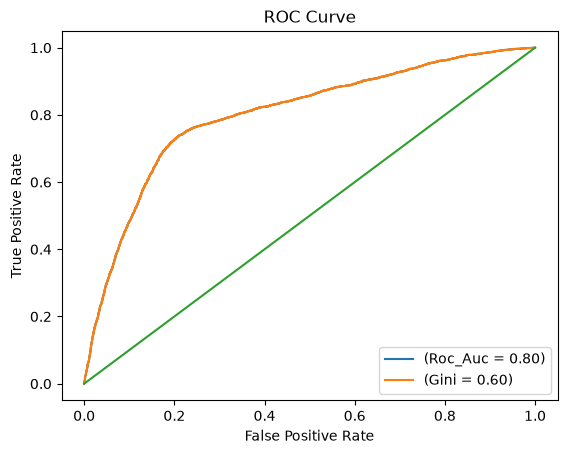

In [91]:
y_prob = clf.predict_proba(X_test_fin)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)
gini = (2*roc_auc_score(y_test, y_prob))-1

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure()

plt.plot(fpr, tpr, label='(Roc_Auc = %0.2f)' % roc_auc)
plt.plot(fpr, tpr, label='(Gini = %0.2f)' % gini)
plt.plot([0, 1], [0, 1])
plt.xlim()
plt.ylim()

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend(loc='lower right')
plt.show()

In [ ]:
# Check univariate Gini for each variable

In [94]:
variables = []
train_gini_scores = []
test_gini_scores = []


for i in X_train_fin.columns:
    X_train_single_var = X_train_fin[[i]]
    X_test_single_var = X_test_fin[[i]]

    
    clf.fit(X_train_single_var, y_train)
    
    y_pred_train_single_var = clf.predict_proba(X_train_single_var)[:, 1]

    train_roc = roc_auc_score(y_train, y_pred_train_single_var)
    train_gini = 2 * train_roc - 1

    
    y_pred_test_single_var = clf.predict_proba(X_test_single_var)[:, 1]

    test_roc = roc_auc_score(y_test, y_pred_test_single_var)
    test_gini = 2 * test_roc - 1


    variables.append(i)
    train_gini_scores.append(train_gini)
    test_gini_scores.append(test_gini)


results_data = pd.DataFrame({
                            'Variable': variables,
                            'Train Gini': train_gini_scores,
                            'Test Gini': test_gini_scores
                        })

results_data_sorted = results_data.sort_values(by='Test Gini', ascending=False)

pd.options.display.float_format = '{:.4f}'.format

results_data_sorted


,Variable,Train Gini,Test Gini
13,OutstandingDebt_woe,0.5160,0.5093
7,InterestRate_woe,0.5021,0.4939
12,NumCreditInquiries_woe,0.4473,0.4280
9,Delayfromduedate_woe,0.4219,0.3970
6,NumCreditCard_woe,0.3878,0.3714
8,NumofLoan_woe,0.3552,0.3485
5,NumBankAccounts_woe,0.3196,0.3165
15,PaymentofMinAmount_woe,0.3047,0.2920
10,NumofDelayedPayment_woe,0.2741,0.2702
3,AnnualIncome_woe,0.2454,0.2476


In [ ]:
# Keep only variables with filters below:

# - train gini > 10%
# - test gini > 10%
# - gini gap between train and test is less than 5%


In [95]:
filtered_data = results_data_sorted[
    (results_data_sorted['Test Gini'] > 0.10) &
    (results_data_sorted['Train Gini'] > 0.10) &
    (abs(results_data_sorted['Train Gini'] - results_data_sorted['Test Gini']) <= 0.05)
]

filtered_data

,Variable,Train Gini,Test Gini
13,OutstandingDebt_woe,0.5160,0.5093
7,InterestRate_woe,0.5021,0.4939
12,NumCreditInquiries_woe,0.4473,0.4280
9,Delayfromduedate_woe,0.4219,0.3970
6,NumCreditCard_woe,0.3878,0.3714
8,NumofLoan_woe,0.3552,0.3485
5,NumBankAccounts_woe,0.3196,0.3165
15,PaymentofMinAmount_woe,0.3047,0.2920
10,NumofDelayedPayment_woe,0.2741,0.2702
3,AnnualIncome_woe,0.2454,0.2476


In [ ]:
# Build a new model using the filtered variables:

# - Retain only the selected variables
# - Train the model using these variables
# - Evaluate the new model's performance

In [97]:
X_train_uni = X_train_fin[filtered_data.Variable.tolist()]
X_train_uni

,OutstandingDebt_woe,InterestRate_woe,NumCreditInquiries_woe,Delayfromduedate_woe,NumCreditCard_woe,NumofLoan_woe,NumBankAccounts_woe,PaymentofMinAmount_woe,NumofDelayedPayment_woe,AnnualIncome_woe,MonthlyBalance_woe,MonthlyInhandSalary_woe,PaymentBehaviour_woe,Age_woe,TotalEMIpermonth_woe,Amountinvestedmonthly_woe
27300,1.2071,-0.0350,0.5597,-0.1029,0.0662,0.3109,0.3302,0.9859,0.6537,-0.1874,0.6761,-0.1678,0.3892,0.4984,-0.1370,-0.1310
81811,-1.2334,-1.3800,-1.0767,-1.1056,-0.0814,-0.9642,-0.3751,-0.0270,-0.2816,-0.1874,-0.4826,-0.1678,0.0704,-0.0624,-0.1049,0.3531
59756,1.2751,1.1461,0.5597,1.0762,1.0698,0.9234,0.7679,0.9859,0.3279,-0.1874,-0.4826,-0.1678,-0.3192,-0.1148,0.4461,0.3531
33786,1.2751,0.9777,1.1194,0.4979,-0.0814,0.9234,-0.3751,-0.0270,-0.2816,-0.5443,-0.2425,-0.4718,-0.0729,-0.1148,0.4461,-0.1310
29284,1.2071,0.9777,0.5597,1.0762,0.0662,0.9234,0.7679,-0.0270,0.3279,-0.1874,0.6761,-0.1678,0.0071,0.4984,-0.1370,0.0183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,-0.3414,0.9777,0.5597,-1.1056,1.0698,0.3109,0.7679,0.9859,-0.2816,-0.1874,0.2173,0.1783,0.3892,-0.1148,-0.1370,-0.1310
54886,1.2071,-0.0350,0.5597,1.0762,1.0698,0.3109,0.3302,-0.0270,0.3279,-0.5443,-0.2425,-0.4718,-0.3192,-0.0624,0.4461,-0.2011
76820,1.2751,0.9777,0.5597,1.0762,0.0662,0.9234,-0.7899,0.9859,-0.6470,0.2319,0.2173,0.1783,0.0905,-0.1148,0.4461,-0.1310
860,-1.2334,0.9777,0.5597,-0.1029,-0.0814,0.3109,0.7679,-0.4758,-0.2816,-0.5443,-0.4826,-0.4718,0.0071,-0.2243,0.4461,0.0183


In [98]:
X_test_uni = X_test_fin[filtered_data.Variable.tolist()]
X_test_uni

,OutstandingDebt_woe,InterestRate_woe,NumCreditInquiries_woe,Delayfromduedate_woe,NumCreditCard_woe,NumofLoan_woe,NumBankAccounts_woe,PaymentofMinAmount_woe,NumofDelayedPayment_woe,AnnualIncome_woe,MonthlyBalance_woe,MonthlyInhandSalary_woe,PaymentBehaviour_woe,Age_woe,TotalEMIpermonth_woe,Amountinvestedmonthly_woe
7777,-1.2334,-0.0350,-1.0767,-1.1056,0.0662,0.9234,-0.7899,-0.4758,-0.6470,0.6756,0.6761,0.5952,0.1771,0.4984,-0.1493,0.0183
13022,1.2071,-1.3800,0.5597,1.0762,0.0662,0.9234,0.7679,-0.4758,-0.6470,0.2319,0.2173,-0.4718,-0.0729,0.4984,0.4461,-0.1310
47762,1.2751,1.1461,-0.4759,0.4979,0.0662,-0.9642,0.3302,-0.4758,0.3279,0.6756,0.6761,0.5952,0.0071,-0.1148,-0.1049,0.0183
75611,-1.2334,-1.3800,-1.0767,-1.1056,-1.2423,-0.9642,0.3302,-0.0270,0.3279,-0.1874,0.6761,-0.1678,0.1771,-0.1148,-0.1049,-0.1310
58979,1.2071,1.1461,0.5597,0.4979,1.0698,0.9234,0.7679,-0.0270,0.3279,0.2319,-0.4826,-0.4718,0.0071,0.4984,0.4461,0.0183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69895,1.2751,1.1461,0.5597,1.0762,0.0662,-0.1091,0.7679,-0.0270,-0.6470,0.2319,-0.2425,0.1783,-0.0729,-0.0624,-0.1493,0.0183
47851,1.2071,1.1461,1.1194,0.4979,-0.0814,0.9234,0.3302,0.9859,0.6537,0.2319,-0.2425,-0.4718,0.0704,-0.0624,0.4461,-0.1310
53387,1.2071,-0.0350,1.1194,1.0762,1.0698,0.3109,0.3302,-0.4758,-0.2816,0.2319,-0.2425,0.1783,-0.3192,-0.1148,-0.1049,0.3531
68372,-1.2334,-1.3800,-0.4759,-0.1029,-0.0814,-0.9642,-0.7899,-0.0270,-0.6470,-0.5443,-0.2425,-0.4718,-0.3192,-0.2243,0.4461,-0.2011


In [99]:
clf_uni = LogisticRegression()
clf_uni.fit(X_train_uni, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [100]:
result_uni = evaluate(clf_uni, X_train_uni, y_train, X_test_uni, y_test)

result_uni

(  Dataset    Gini  Precision  Recall
 0   Train 59.5259     0.6356  0.5665
 1    Test 57.7681     0.6236  0.5586,
 array([[10722,  1709],
        [ 2237,  2831]]))

# Deployment with woe

In [108]:
deployment_data = pd.read_excel("C:/Users/aksta/Desktop/python lessons/deployment_data_with_woe.xlsx")

deployment_X = deployment_data[filtered_data.Variable.tolist()]

pd_scores = clf_uni.predict_proba(deployment_X)[:, 1]

deployment_data['PD'] = pd_scores

deployment_data.head()

,Month_woe,Age_woe,Occupation_woe,AnnualIncome_woe,MonthlyInhandSalary_woe,NumBankAccounts_woe,NumCreditCard_woe,InterestRate_woe,NumofLoan_woe,Delayfromduedate_woe,NumofDelayedPayment_woe,ChangedCreditLimit_woe,NumCreditInquiries_woe,OutstandingDebt_woe,CreditUtilizationRatio_woe,PaymentofMinAmount_woe,TotalEMIpermonth_woe,Amountinvestedmonthly_woe,PaymentBehaviour_woe,MonthlyBalance_woe,PD
0,0.0123,-0.2243,0.0935,-0.5443,-0.4718,-0.7899,1.0698,0.9777,0.9234,1.0762,-0.2816,0.0339,0.5597,1.2751,-0.0082,0.9859,-0.1049,0.0183,-0.0729,-0.4826,0.0707
1,0.0254,-0.0624,0.1059,-0.1874,0.1783,0.7679,-0.0814,0.9777,0.3109,1.0762,0.3279,0.1081,1.1194,1.2071,-0.0082,0.9859,-0.1370,0.0183,-0.3192,0.2173,0.1365
2,-0.0180,-0.0624,-0.0508,0.2319,-0.4718,-0.7899,-1.2423,-1.3800,-0.9642,-0.1029,0.3279,-0.2557,-1.0767,-1.2334,-0.0826,-0.4758,-0.1493,-0.2011,-0.0729,-0.2425,0.7237
3,0.0249,-0.0624,0.0935,-0.1874,-0.1678,0.3302,1.0698,-0.0350,-0.1091,-0.1029,-0.2816,-0.2557,0.5597,1.2071,-0.0082,-0.4758,-0.1493,-0.1310,0.1771,0.2173,0.1127
4,-0.0029,-0.2243,0.0359,-0.5443,-0.4718,-0.7899,1.0698,-0.0350,0.3109,1.0762,0.3279,-0.2557,-1.0767,1.2751,-0.0082,-0.4758,0.4461,-0.1310,0.0704,-0.2425,0.1271


# Deployment with real values (homework)

In [111]:
deployment_real = pd.read_excel('C:/Users/aksta/Desktop/python lessons/deployment_data_with_real.xlsx')
deployment_real_woe = deployment_real.copy()

for var in features:
    if pd.api.types.is_numeric_dtype(deployment_real[var]):
        dep_bin = pd.cut(deployment_real[var], bins=bin_maps[var], duplicates='drop')
        deployment_real_woe[var + '_woe'] = dep_bin.map(woe_maps[var])
    else:
        deployment_real_woe[var + '_woe'] = deployment_real[var].map(woe_maps[var])

deployment_X_real = deployment_real_woe[filtered_data.Variable.tolist()]


pd_scores_real = clf_uni.predict_proba(deployment_X_real)[:, 1]

deployment_real['PD'] = pd_scores_real

deployment_real['Decision'] = np.where(deployment_real['PD'] > 0.25, 'Reject', 'Approve')

deployment_real.head()
                            

,Month,Age,Occupation,AnnualIncome,MonthlyInhandSalary,NumBankAccounts,NumCreditCard,InterestRate,NumofLoan,Delayfromduedate,NumofDelayedPayment,ChangedCreditLimit,NumCreditInquiries,OutstandingDebt,CreditUtilizationRatio,PaymentofMinAmount,TotalEMIpermonth,Amountinvestedmonthly,PaymentBehaviour,MonthlyBalance,PD,Decision
0,May,33,Scientist,74450.8800,6139.2400,6,4,19,3,5,20.0000,16.8500,27.7343,640.7000,33.4069,Yes,120.8466,255.9744,HighspentMediumvaluepayments,487.1031,0.1177,Approve
1,April,28,Doctor,19823.5650,1782.9637,1,3,6,3,19,12.0000,1.0000,4.0000,1408.6600,39.0388,No,35.5763,30.7502,HighspentLargevaluepayments,351.9699,0.1818,Approve
2,June,41,Musician,70154.8500,4193.1813,8,5,18,2,27,7.0000,14.2300,0.0000,487.4200,24.7873,Yes,92.8883,532.2687,LowspentLargevaluepayments,214.4668,0.1166,Approve
3,May,54,Mechanic,115724.4000,4193.1813,3,6,10,2,14,30.9043,8.5400,8.0000,1480.9800,33.6650,No,149.2013,169.6806,HighspentLargevaluepayments,907.9882,0.2053,Approve
4,July,24,Teacher,40198.9600,3424.9133,4,6,10,2,4,18.0000,0.5800,1.0000,530.0400,38.6980,No,39.9605,183.1175,HighspentSmallvaluepayments,379.4133,0.0815,Approve
